In [1]:
import pandas as pd
import re
import torch

#libraries for data explore
import seaborn as sns
import matplotlib.pyplot as plt

#libraries for Model training and evaluation
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

/opt/anaconda3/lib/python3.13/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/anaconda3/lib/python3.13/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/anaconda3/lib/python3.13/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [2]:
# Example: Load a CSV dataset
df = pd.read_csv("phishing_email.csv")


df.shape

(82486, 2)

In [3]:
# Randomly sample 15,000 rows from the full dataset
df = df.sample(n=15000, random_state=42).reset_index(drop=True)

print(df.head())

                                       text_combined  label
0  endangered languages workshop foundation endan...      0
1  claretta claretta_bordersfusemailcom cialis wo...      1
2  roger upole schkeramsncom kyle rickey wrote im...      0
3  barclays customer service testlightworldcojp d...      1
4  gmm 09 nov 2001 please find attached global ma...      0


In [4]:
# Remove nulls
df.dropna(inplace=True)

# Convert label
df['label'] = df['label'].astype(int)

# Lowercasing
df['text_combined'] = df['text_combined'].apply(lambda x: x.lower())

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  15000 non-null  object
 1   label          15000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 234.5+ KB
None


In [6]:
df.shape

(15000, 2)

In [7]:
df.tail()

,text_combined,label
14995,winning notification dalobica lotto bv interna...,1
14996,become happy performance girlfriend loves resu...,1
14997,looks good obviously close originally suggest...,0
14998,cnn alerts frakte_1973emmeffenet cnn alerts cu...,1
14999,danny graham ingridchianghadleybuytaertnet syo...,1


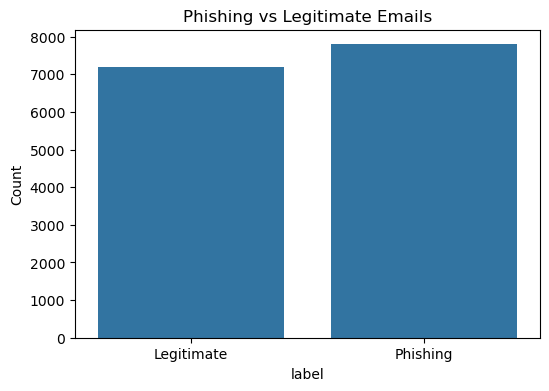

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label') # counts the number of occurrences of each unique value in a column
plt.title('Phishing vs Legitimate Emails')
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.ylabel('Count')
plt.show()

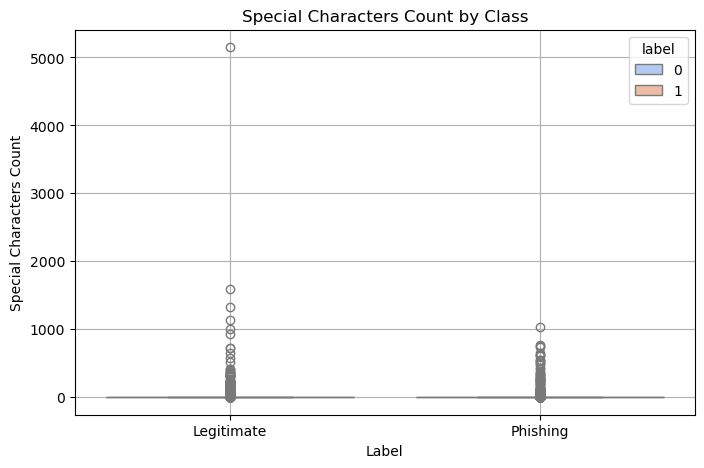

In [9]:
#compare number of special characters in phising vs legitimate emails
df['special_chars'] = df['text_combined'].apply(lambda x: sum(not c.isalnum() and not c.isspace() for c in x))

plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='special_chars', data=df, hue='label', palette='coolwarm', dodge=False)

plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.title('Special Characters Count by Class')
plt.xlabel('Label')
plt.ylabel('Special Characters Count')
plt.grid(True)
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kasmyabhatia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


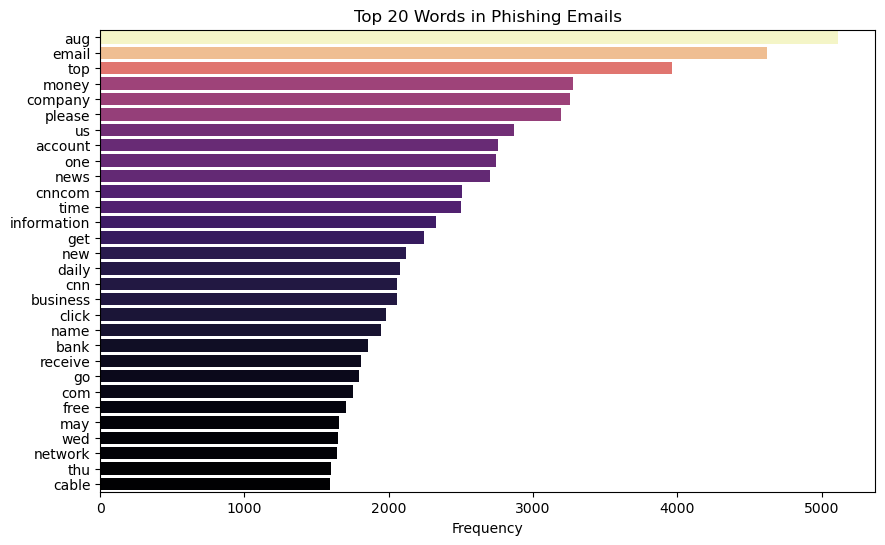

In [10]:
#analyzing common words in phising emails
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


stop_words = set(stopwords.words('english'))  #e.g., "the", "is", "and"

# Combine all phishing emails: Joins all texts into one string → converts to lowercase → splits into words
phishing_words = ' '.join(df[df['label']==1]['text_combined']).lower().split() #Selects only phishing emails (where label == 1)

filtered_words = [word for word in phishing_words if word.isalpha() and word not in stop_words] #Alphabetic words (removes numbers, punctuation)

word_freq = Counter(filtered_words).most_common(30)

# Barplot of top words
words, counts = zip(*word_freq)  #Unpacks the 20 most common word–count pairs into two separate lists: words and counts
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words),hue =list(counts), palette='magma',legend=False)
plt.title('Top 20 Words in Phishing Emails')
plt.xlabel('Frequency')
plt.show()

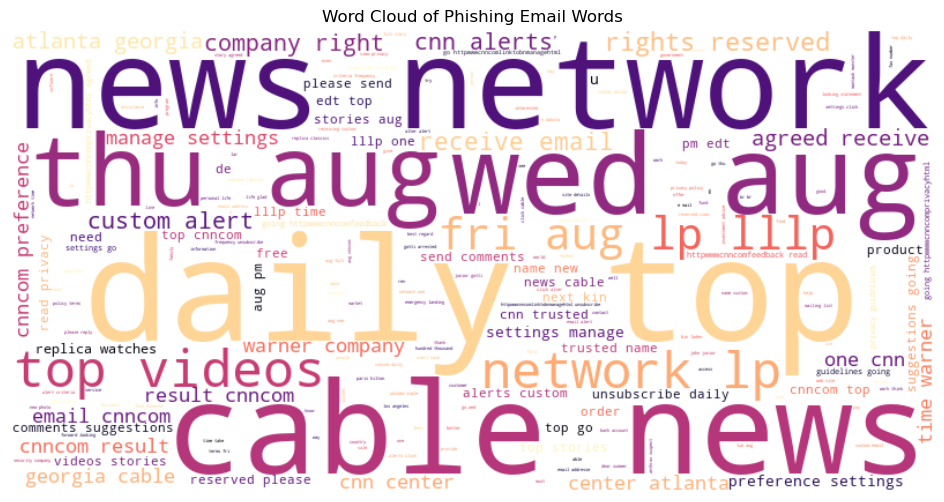

In [11]:
from wordcloud import WordCloud

# Join all filtered phishing words into a single string
wordcloud_text = ' '.join(filtered_words)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Phishing Email Words')
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

# 1. First, split out 20% test data

train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(df['text_combined'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42, stratify=df['label'])

# 2. Then split remaining 80% into 70% train and 10% val

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels,
    test_size=0.125,  # 10% of total = 12.5% of the remaining 80%
    random_state=42, stratify=train_val_labels
)

In [13]:
#tokenization using bert tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Tokenize the datasets
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=128
)

/opt/anaconda3/lib/python3.13/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [14]:
print(train_encodings['input_ids'][0])          # View input IDs of the first text
print(train_encodings['attention_mask'][0]) 

[101, 17264, 7027, 2373, 3001, 3204, 3283, 2218, 3116, 5395, 3288, 2362, 3001, 3136, 3293, 2111, 3625, 12697, 2311, 17264, 7027, 3001, 2763, 3174, 2111, 2164, 7014, 2566, 12624, 4938, 2154, 7113, 7014, 10439, 14511, 2080, 3960, 2534, 8886, 17891, 6746, 6927, 3902, 3762, 6754, 24185, 21007, 2063, 7369, 2014, 19333, 6264, 6606, 3889, 14085, 5076, 20105, 16215, 6072, 2050, 5297, 11623, 2928, 27078, 8512, 6519, 10524, 2116, 2048, 17817, 4484, 3116, 2034, 3154, 9129, 2111, 2551, 9033, 10483, 7014, 2177, 3225, 2831, 4938, 2177, 2609, 6337, 2136, 3931, 20105, 9352, 26351, 2014, 19333, 25212, 2015, 4372, 2050, 3043, 2264, 4372, 2050, 2225, 4372, 2050, 3872, 2968, 19387, 2080, 7617, 2111, 3331, 2028, 2178, 2117, 3154, 6343, 2699, 4949, 4072, 4972, 4906, 2362, 13487, 6927, 3902, 3762, 102]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [15]:
#data input format for bert
class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
        
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmailDataset(train_encodings, train_labels)
val_dataset = EmailDataset(val_encodings, val_labels)

In [16]:
#load pretrained bert for classification
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary', zero_division=1
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [18]:
training_args = TrainingArguments(
    output_dir="./results",

    max_steps=300,
    per_device_train_batch_size=8,

    learning_rate=2e-5,
    weight_decay=0.01,
    label_smoothing_factor=0.1,

    evaluation_strategy="steps",
    eval_steps=100,
    load_best_model_at_end=True,

    save_strategy="steps",
    save_steps=100,

    metric_for_best_model="f1",
    greater_is_better=True,

    logging_steps=100,

    report_to="none",
    disable_tqdm=True
)

In [20]:
from accelerate import Accelerator

# 🔥 Patch to ignore unsupported args like 'dispatch_batches'
class PatchedAccelerator(Accelerator):
    def __init__(self, *args, **kwargs):
        kwargs.pop("dispatch_batches", None)
        super().__init__(*args, **kwargs)

# Inject patch into transformers Trainer
import transformers.trainer
transformers.trainer.Accelerator = PatchedAccelerator

In [21]:
from transformers import Trainer, DataCollatorWithPadding, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [22]:
from torch.utils.data import Subset
import random

# random 2000 samples 
indices = random.sample(range(len(trainer.train_dataset)), 2000)

trainer.train_dataset = Subset(trainer.train_dataset, indices)

In [23]:
indices_val = random.sample(range(len(trainer.eval_dataset)), 500)

trainer.eval_dataset = Subset(trainer.eval_dataset, indices_val)

In [24]:
trainer.train()

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'loss': 0.476, 'learning_rate': 1.3333333333333333e-05, 'epoch': 0.4}
{'eval_loss': 0.34728002548217773, 'eval_accuracy': 0.912, 'eval_f1': 0.9130434782608695, 'eval_precision': 0.8716981132075472, 'eval_recall': 0.9585062240663901, 'eval_runtime': 6.1047, 'eval_samples_per_second': 81.904, 'eval_steps_per_second': 10.32, 'epoch': 0.4}
{'loss': 0.2902, 'learning_rate': 6.666666666666667e-06, 'epoch': 0.8}


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.3338296115398407, 'eval_accuracy': 0.926, 'eval_f1': 0.9227557411273486, 'eval_precision': 0.9285714285714286, 'eval_recall': 0.91701244813278, 'eval_runtime': 6.2549, 'eval_samples_per_second': 79.937, 'eval_steps_per_second': 10.072, 'epoch': 0.8}


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'loss': 0.288, 'learning_rate': 0.0, 'epoch': 1.2}
{'eval_loss': 0.31980401277542114, 'eval_accuracy': 0.932, 'eval_f1': 0.9300411522633745, 'eval_precision': 0.9224489795918367, 'eval_recall': 0.9377593360995851, 'eval_runtime': 6.759, 'eval_samples_per_second': 73.976, 'eval_steps_per_second': 9.321, 'epoch': 1.2}
{'train_runtime': 137.353, 'train_samples_per_second': 17.473, 'train_steps_per_second': 2.184, 'train_loss': 0.3514292780558268, 'epoch': 1.2}


TrainOutput(global_step=300, training_loss=0.3514292780558268, metrics={'train_runtime': 137.353, 'train_samples_per_second': 17.473, 'train_steps_per_second': 2.184, 'train_loss': 0.3514292780558268, 'epoch': 1.2})

In [25]:
trainer.evaluate()

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.31980401277542114, 'eval_accuracy': 0.932, 'eval_f1': 0.9300411522633745, 'eval_precision': 0.9224489795918367, 'eval_recall': 0.9377593360995851, 'eval_runtime': 6.1523, 'eval_samples_per_second': 81.271, 'eval_steps_per_second': 10.24, 'epoch': 1.2}


{'eval_loss': 0.31980401277542114,
 'eval_accuracy': 0.932,
 'eval_f1': 0.9300411522633745,
 'eval_precision': 0.9224489795918367,
 'eval_recall': 0.9377593360995851,
 'eval_runtime': 6.1523,
 'eval_samples_per_second': 81.271,
 'eval_steps_per_second': 10.24,
 'epoch': 1.2}

In [26]:
preds = trainer.predict(val_dataset)

import numpy as np
labels = preds.label_ids
predictions = np.argmax(preds.predictions, axis=1)

print("Unique predictions:", set(predictions))
print("Accuracy:", (predictions == labels).mean())

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Unique predictions: {np.int64(0), np.int64(1)}
Accuracy: 0.9453333333333334


In [27]:
train_texts_set = set(train_texts)
val_texts_set = set(val_texts)

overlap = train_texts_set.intersection(val_texts_set)

print("Overlap samples:", len(overlap))

Overlap samples: 3


In [28]:
import numpy as np
from scipy.special import softmax

probs = softmax(preds.predictions, axis=1)
conf = np.max(probs, axis=1)

print("Avg confidence:", np.mean(conf))

Avg confidence: 0.93389565


In [29]:
# Save your trained model and tokenizer
model.save_pretrained("./phishing_model")
tokenizer.save_pretrained("./phishing_model")
print("✅ Model saved successfully to ./phishing_model")

✅ Model saved successfully to ./phishing_model
